## Importación de Librerías

En esta sección se importan las librerías necesarias para el análisis y limpieza de datos.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy

pd.options.future.infer_string = False

## Carga y Exploración Inicial

Se carga el dataset y se realiza una inspección inicial.

In [36]:
df = pd.read_csv('../data/Telco_Customer_Churn_Clean.csv')

In [37]:
#vista Preliminar del dataset
print('Informacion del dataset', df.shape)
print('\nColumnas del dataset: ')
print(list(df.columns))
print('\nTipo de datos:')
print(df.dtypes)

Informacion del dataset (7032, 23)

Columnas del dataset: 
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'TotalServices']

Tipo de datos:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService      object
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn    

In [38]:
#Cambiar el tipo de datos de Totalcharges nuevamente ya que pandas no guarda estos cambios al pasar de un dataset a uno nuevo.

#Conversion a tipo numerico con error='coerce', al encontrar un valor que no puede convertir a numero lo convertira en NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Tipo de dato de la columna TotalCharges Despues del cambio: {df['TotalCharges'].dtypes}')


Tipo de dato de la columna TotalCharges Despues del cambio: float64


# Visualización de los datos

En esta etapa se realizará un Análisis Exploratorio de Datos (EDA) con el objetivo de identificar patrones y relaciones que permitan comprender los factores asociados al abandono de clientes (**Churn**).

Cada visualización responderá una pregunta de negocio específica y estará acompañada de estadísticas descriptivas que respalden los resultados obtenidos.

### Pregunta 1

## ¿Existe un desbalance entre los clientes que abandonan y los que permanecen?

Antes de analizar las características de los clientes, es importante conocer la distribución de la variable objetivo (**Churn**). Esto permitirá determinar si el conjunto de datos presenta un desbalance entre clientes que permanecen en la empresa y aquellos que abandonan el servicio.

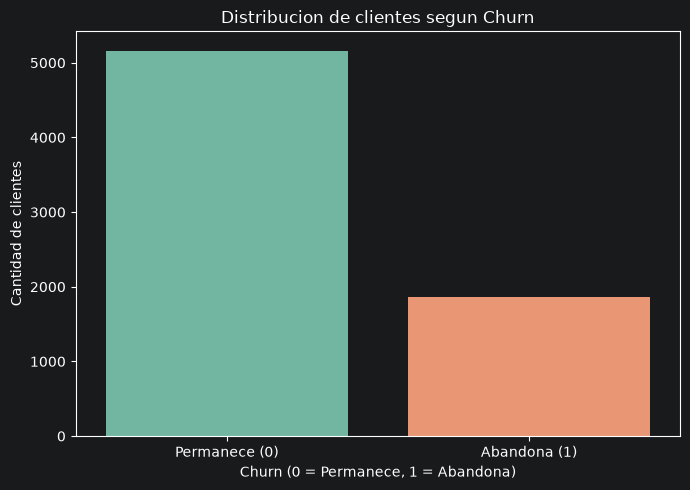

Churn
0    5163
1    1869
Name: count, dtype: int64


Porcentaja de Abandono: Churn
0    73.42
1    26.58
Name: count, dtype: float64%

Total de clientes: 7032


In [39]:
plt.figure(figsize = (7, 5))

sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Distribucion de clientes segun Churn')
plt.xlabel('Churn (0 = Permanece, 1 = Abandona)')
plt.ylabel('Cantidad de clientes')
plt.xticks([0,1], ['Permanece (0)', 'Abandona (1)'])

plt.tight_layout()
plt.savefig('../graficas/01_churn.png')
plt.show()

print(df['Churn'].value_counts())
print()
print(f'\nPorcentaja de Abandono: {(df["Churn"].value_counts()/len(df)*100).round(2)}%')
print(f'\nTotal de clientes: {len(df)}')

### Interpretación

Se observa que la mayoría de los clientes permanece en la empresa, mientras que una menor proporción corresponde a clientes que abandonan el servicio. Este comportamiento indica la presencia de un **desbalance moderado** en la variable objetivo, aspecto que deberá considerarse durante el entrenamiento y evaluación de los modelos de Machine Learning.

### Pregunta 2

## ¿Qué tipo de contrato presenta la mayor tasa de abandono?

El tipo de contrato puede influir en la permanencia de los clientes dentro de la empresa. En esta visualización se analiza la tasa promedio de abandono (`Churn`) según el tipo de contrato, con el fin de identificar cuáles modalidades presentan un mayor riesgo de pérdida de clientes.

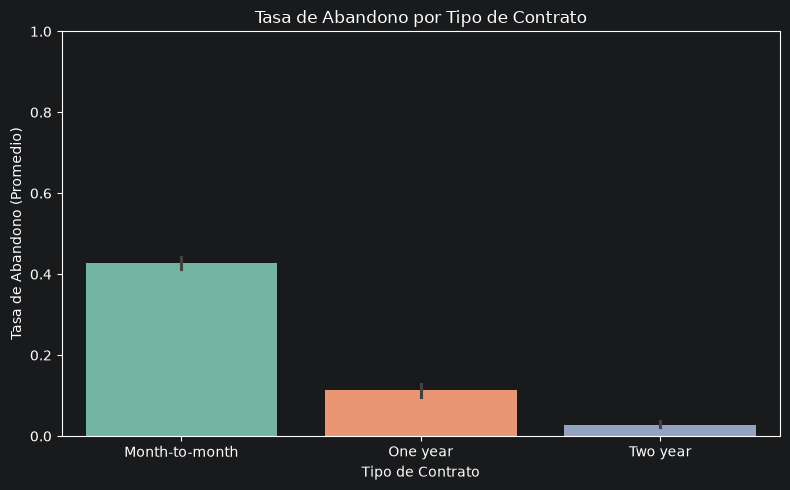

Tasa de Abandono por tipo de contrato:
                mean  count
Contract                   
Month-to-month  0.43   3875
One year        0.11   1472
Two year        0.03   1685


In [40]:
plt.figure(figsize= (8,5))

sns.barplot(data=df, x='Contract', y='Churn', hue='Contract', palette='Set2', legend=False)
plt.title('Tasa de Abandono por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Tasa de Abandono (Promedio)')
plt.ylim(0,1)

plt.tight_layout()
plt.savefig('../graficas/02.contract_churn.png')
plt.show()

print('Tasa de Abandono por tipo de contrato:')
print(df.groupby('Contract')['Churn'].agg(['mean', 'count']).round(2))


### Interpretación

Los clientes con contratos **mensuales (Month-to-month)** presentan la mayor tasa de abandono en comparación con los contratos de uno y dos años. Esto sugiere que los compromisos contractuales de mayor duración favorecen la permanencia de los clientes y reducen la probabilidad de cancelación del servicio.

Este hallazgo puede servir como base para diseñar estrategias comerciales orientadas a incentivar la migración de clientes hacia contratos de mayor duración.

### Pregunta 3

## ¿Los clientes nuevos presentan una mayor tasa de abandono?

Con el objetivo de analizar si la antigüedad del cliente influye en su permanencia dentro de la empresa, se utilizará la variable **TenureGroup**, creada durante la etapa de *Feature Engineering*. Esta variable agrupa a los clientes según su tiempo de permanencia, permitiendo comparar la tasa de abandono entre clientes nuevos, estables, leales y veteranos.

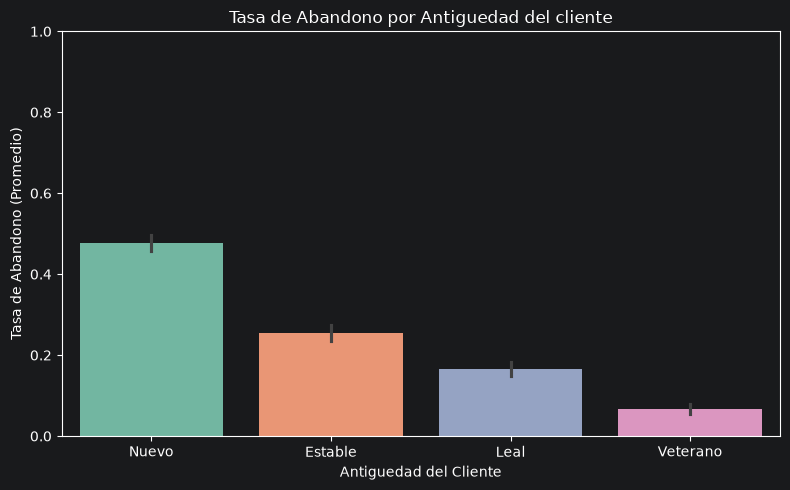

Tasa de Abanadono por Antiguedad del Cliente:

             mean  count
TenureGroup             
Estable      0.26   1856
Leal         0.17   1594
Nuevo        0.48   2175
Veterano     0.07   1407


In [41]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x='TenureGroup', y='Churn', hue='TenureGroup', palette='Set2', legend=False)
plt.title('Tasa de Abandono por Antiguedad del cliente')
plt.xlabel('Antiguedad del Cliente')
plt.ylabel('Tasa de Abandono (Promedio)')
plt.ylim(0,1)

plt.tight_layout()
plt.savefig('../graficas/03_tenure_group_churn.png')
plt.show()

print('Tasa de Abanadono por Antiguedad del Cliente:')
print(f'\n{df.groupby('TenureGroup', observed=True)['Churn'].agg(['mean', 'count']).round(2)}')

### Interpretación

Se observa que los clientes con menor antigüedad presentan una mayor tasa de abandono, mientras que la probabilidad de cancelar el servicio disminuye conforme aumenta el tiempo de permanencia en la empresa.

Este comportamiento sugiere que los primeros meses representan una etapa crítica en la relación con el cliente. Por ello, la empresa podría implementar programas de fidelización, seguimiento personalizado o incentivos durante el primer año de servicio para reducir el riesgo de abandono.

### Pregunta 4

## ¿Los clientes con una mayor cantidad de servicios presentan una menor tasa de abandono?

Durante la etapa de *Feature Engineering* se creó la variable **TotalServices**, la cual representa la cantidad total de servicios contratados por cada cliente. Esta visualización permitirá analizar si existe una relación entre el nivel de utilización de los servicios y la probabilidad de abandono.

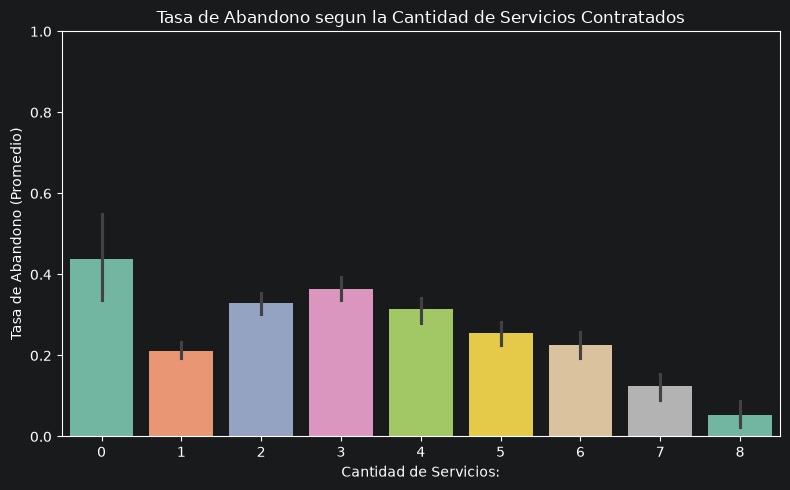

Tasa de Abandono por Cantidad de Servicios Contratados:
               mean  count
TotalServices             
0              0.44     80
1              0.21   1697
2              0.33   1186
3              0.36    965
4              0.31    921
5              0.26    906
6              0.23    674
7              0.12    395
8              0.05    208


In [42]:
plt.figure(figsize=(8,5))

sns.barplot(data =df, x='TotalServices', y='Churn', hue='TotalServices', palette='Set2', legend=False)
plt.title('Tasa de Abandono segun la Cantidad de Servicios Contratados')
plt.xlabel('Cantidad de Servicios:')
plt.ylabel('Tasa de Abandono (Promedio)')
plt.ylim(0,1)

plt.tight_layout()
plt.savefig('../graficas/04_totalservices_churn.png')
plt.show()

print('Tasa de Abandono por Cantidad de Servicios Contratados:')
print(df.groupby('TotalServices', observed=True)['Churn'].agg(['mean', 'count']).round(2))


### Interpretación

La visualización permite analizar la relación entre la cantidad de servicios contratados y la tasa de abandono de los clientes. En general, se observa que los clientes con un mayor número de servicios presentan una menor probabilidad de abandonar la empresa.

Este comportamiento sugiere que la contratación de servicios adicionales fortalece la relación del cliente con la compañía, incrementando su nivel de fidelización. Como estrategia de negocio, la empresa podría promover la venta de servicios complementarios para reducir el riesgo de abandono.

### Pregunta 5

## ¿Los cargos mensuales influyen en el abandono de los clientes?

Los cargos mensuales representan el costo que cada cliente paga por los servicios contratados. En esta visualización se analizará si existe una diferencia en la distribución de los pagos mensuales entre los clientes que permanecen en la empresa y aquellos que deciden abandonar el servicio.

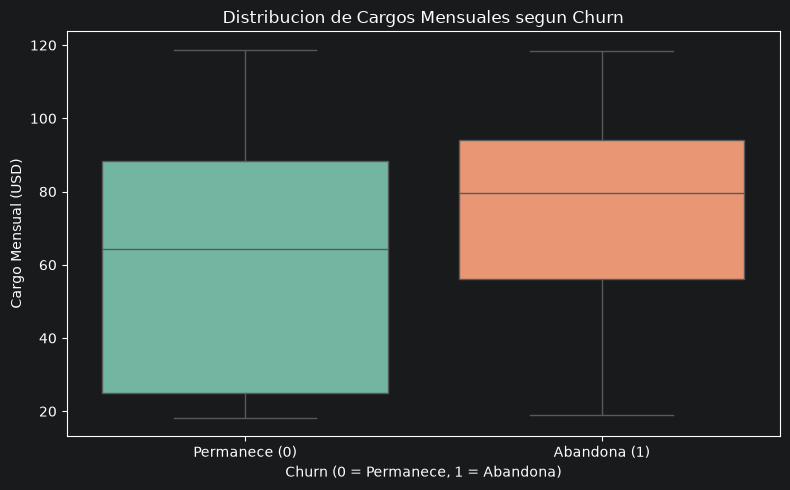

Estadisticas de MonthlyCharges segun Churn:
        count   mean    std    min    25%    50%    75%     max
Churn                                                          
0      5163.0  61.31  31.09  18.25  25.10  64.45  88.48  118.75
1      1869.0  74.44  24.67  18.85  56.15  79.65  94.20  118.35


In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette='Set2', legend=False)

plt.title('Distribucion de Cargos Mensuales segun Churn')
plt.xlabel('Churn (0 = Permanece, 1 = Abandona)')
plt.ylabel('Cargo Mensual (USD)')
plt.xticks([0,1], ['Permanece (0)', 'Abandona (1)'])

plt.tight_layout()
plt.savefig('../graficas/05_monthlycharges_churn.png')
plt.show()

print('Estadisticas de MonthlyCharges segun Churn:')
print(df.groupby('Churn')['MonthlyCharges'].describe().round(2))

### Interpretación

La distribución de los cargos mensuales muestra diferencias entre los clientes que permanecen y aquellos que abandonan la empresa. En promedio, los clientes que cancelan el servicio presentan cargos mensuales más elevados.

Este resultado sugiere que el costo del servicio podría ser un factor asociado al abandono de clientes. Como posible estrategia de negocio, la empresa podría evaluar planes de retención, descuentos personalizados o paquetes promocionales dirigidos a clientes con cargos mensuales elevados.

### Pregunta 6

## ¿Qué variables numéricas presentan una mayor relación con el abandono de clientes?

Se analizará la correlación entre las variables numéricas del dataset con el objetivo de identificar cuáles presentan una mayor asociación con la variable objetivo **Churn**. Este análisis permitirá conocer qué características podrían aportar mayor información durante el entrenamiento del modelo.

In [44]:
columnas_numericas = df.select_dtypes(include=['int64', 'float64'])

print('Columnas numericas:')
print(list(columnas_numericas.columns))

Columnas numericas:
['SeniorCitizen', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TotalServices']


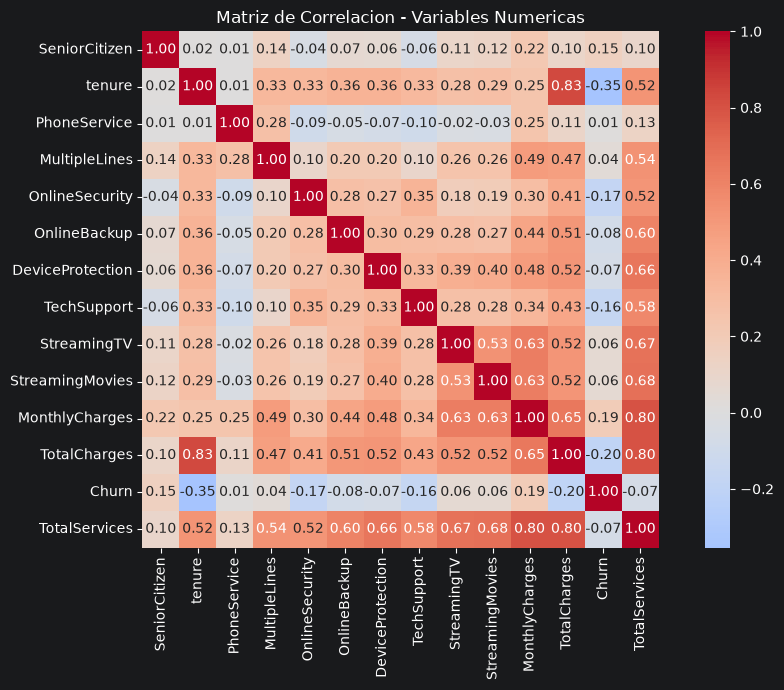

Correlacion de las variables numericas con Churn:
Churn               1.000
MonthlyCharges      0.193
SeniorCitizen       0.151
StreamingTV         0.063
StreamingMovies     0.061
MultipleLines       0.040
PhoneService        0.012
DeviceProtection   -0.066
TotalServices      -0.067
OnlineBackup       -0.082
TechSupport        -0.165
OnlineSecurity     -0.171
TotalCharges       -0.199
tenure             -0.354
Name: Churn, dtype: float64


In [45]:
#calcular la matriz de correlacion

correlacion = columnas_numericas.corr()

#Visualizacion

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
)

plt.title('Matriz de Correlacion - Variables Numericas')

plt.tight_layout()
plt.savefig('../graficas/06_corr_matrix.png')
plt.show()

print("Correlacion de las variables numericas con Churn:")
print(correlacion['Churn'].sort_values(ascending=False).round(3))

### Interpretación

 Se observa que variables como **tenure** y **TotalCharges** presentan una correlación negativa con el abandono, lo que sugiere que los clientes con mayor permanencia o mayor inversión acumulada tienden a permanecer en la empresa. Por otro lado, variables como **MonthlyCharges** muestran una correlación positiva, indicando que cargos mensuales más elevados podrían estar asociados con una mayor probabilidad de abandono.

Aunque las correlaciones individuales no son muy altas, este comportamiento es común en problemas de clasificación, donde la combinación de múltiples variables suele ofrecer un mayor poder predictivo que el análisis de una sola característica.